### Digital Chemical Reactions — Seminar Notebook

In this seminar, we will explore how chemical reactions can be represented, analyzed, and simulated using computational tools.

We will work with:

- SMARTS patterns for substructure matching
- Reaction SMARTS for encoding chemical transformations
- Digital reaction workflows using RDKit

The objective is to understand how chemical reactivity can be translated into formal rules and applied programmatically to molecular structures.

In [1]:
# Imports
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd
from rdkit.Chem import AllChem
from rdkit.Chem import SDWriter, SDMolSupplier
from rdkit.Chem import rdChemReactions

#### 0.1 SMILES from CSV file

In many real-world scenarios, chemical data is stored in external files like CSVs. Here, we'll load a file with molecule names and their 
corresponding SMILES strings, and visualize them using RDKit.

What is a CSV file?
A CSV (Comma-Separated Values) file is a simple, plain-text file used to store tabular data, where each line represents a row and columns
are separated by commas. 

It's commonly used for exchanging structured data between programs like Excel, Python (via pandas), and databases.

     code_name    SMILES
0      ethanol       CCO
1      benzene  c1ccccc1
2  acetic_acid   CC(=O)O

Number of molecules created: 3

Molecules: [<rdkit.Chem.rdchem.Mol object at 0x00000240E0D02E30>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D02EA0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D02F10>]


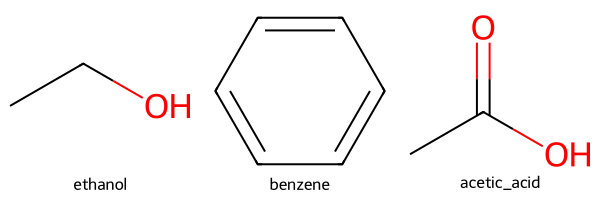

In [2]:
# 1. Load the CSV file into a pandas DataFrame
df = pd.read_csv("data/molecules.csv")
print(df)

# 2. Convert each SMILES string into an RDKit molecule object
molecules = []

for smi in df["SMILES"]:
    mol = Chem.MolFromSmiles(smi)
    molecules.append(mol)

print(f"\nNumber of molecules created: {len(molecules)}")
print(f"\nMolecules: {molecules}")

# 3. Visualize the molecules in a grid
Draw.MolsToGridImage(
    molecules,
    molsPerRow=3,
    subImgSize=(200, 200),
    legends=df["code_name"].tolist()
)

#### 0.2. SMILES from SDF file

Reading molecules from an SDF file

SDF (Structure Data File) is a widely used file format for storing multiple molecular structures along with metadata. 
RDKit can parse these files and convert them into Mol objects.

Below is a demonstration of how to load molecules from an SDF file. You can replace 'nitriles.sdf' with any real dataset.

Number of valid molecules loaded: 22
Molecules: [<rdkit.Chem.rdchem.Mol object at 0x00000240E0D02EA0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D02F10>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D030D0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D02CE0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D031B0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D03220>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D034C0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D03530>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D035A0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D03610>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D03680>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D036F0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D03760>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D037D0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D03840>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D038B0>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0D03920>, <rdkit.Chem.rdchem.Mol object at 

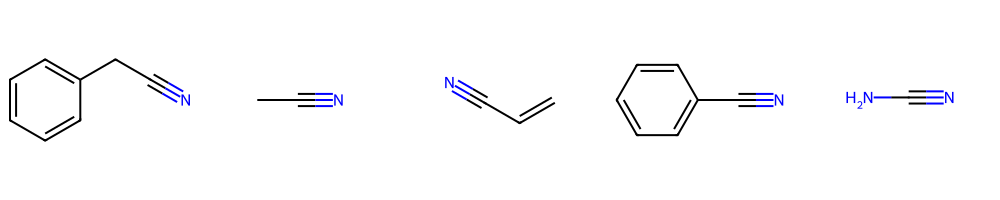

In [3]:
# 1. Load molecules from an SDF file
# The file must be in the same folder as this notebook
supplier = Chem.SDMolSupplier("data/sdf/nitriles.sdf")
print(supplier)

# 2. Convert the supplier into a list of valid molecules
molecules = []

for mol in supplier:
    if mol is not None:  # Skip invalid entries
        molecules.append(mol)

print(f"Number of valid molecules loaded: {len(molecules)}")
print(f"Molecules: {molecules}")    

# 3. Visualize the first 5 molecules
Draw.MolsToGridImage(
    molecules[:5],  # Show only the first 5
    molsPerRow=5,
    subImgSize=(200, 200)
)

Try the following tasks based on what you've learned so far:

1. Load the CSV file again and visualize the molecules.
2. Load your own SDF file and display the first few molecules.

Use the cells below to practice:

### 1. SMARTS

#### 1.0. Introduction to SMARTS

**SMARTS (SMILES Arbitrary Target Specification)** is a powerful language used to define substructures in molecules. While SMILES describes entire molecules, SMARTS allows you to describe **patterns or fragments** to match within molecules, making it ideal for filtering, searching, and performing **digital reactions**.

**Why use SMARTS?**
- Substructure matching in large datasets
- Defining reactants or transformation rules in digital reactions
- Functional group identification

**Some Useful Basic SMARTS Rules**:

1. `[#6]` — Carbon atom (atomic number Z = 6)
2. `[O]` — Oxygen atom
3. `[#7]` — Nitrogen atom (atomic number Z = 7)
4. `[C]=[O]` — Carbon double-bonded to oxygen (carbonyl group)
5. `[OH]` — Hydroxyl group
6. `[CH3]` — Methyl group
7. `[nH]` — Aromatic nitrogen bearing one hydrogen (e.g., in indole)
8. `[R]` — Atom that is part of a ring
9. `[!#6]` — Any atom except carbon
10. `*` — Any atom (wildcard)

**SMARTS Resources**:
- [Daylight SMARTS Tutorial](http://www.daylight.com/dayhtml/doc/theory/theory.smarts.html)
- [RDKit SMARTS Examples](https://www.rdkit.org/docs/Cookbook.html#substructure-matching)
- [SMARTS Tutorial](https://www.daylight.com/dayhtml_tutorials/languages/smarts/)
- [SMARTS Examples](https://www.daylight.com/dayhtml_tutorials/languages/smarts/smarts_examples.html)
- [SMARTS.plus](https://smarts.plus/) — Interactive SMARTS pattern visualizer and tester

#### 1.1. Basic examples of SMARTS

In [4]:
# -----------------------------------------
# 1️⃣ Create a molecule from a SMILES string
# -----------------------------------------

smiles = "CCN(CC)CC"
print("SMILES string:", smiles)

mol = Chem.MolFromSmiles(smiles)

print("Type of mol object:", type(mol))


# -----------------------------------------
# 2️⃣ Define a SMARTS pattern
# -----------------------------------------

# We want to check if the molecule contains nitrogen
smarts_pattern = "N"

print("\nSMARTS pattern:", smarts_pattern)

pattern_mol = Chem.MolFromSmarts(smarts_pattern)

print("Type of SMARTS object:", type(pattern_mol))


# -----------------------------------------
# 3️⃣ Check if the pattern is present
# -----------------------------------------

contains_nitrogen = mol.HasSubstructMatch(pattern_mol)

print("\nDoes the molecule contain nitrogen?")
print(contains_nitrogen)
print("Type of result:", type(contains_nitrogen))

SMILES string: CCN(CC)CC
Type of mol object: <class 'rdkit.Chem.rdchem.Mol'>

SMARTS pattern: N
Type of SMARTS object: <class 'rdkit.Chem.rdchem.Mol'>

Does the molecule contain nitrogen?
True
Type of result: <class 'bool'>


### Why is this useful?

`HasSubstructMatch()` returns a boolean (`True` or `False`), so we can use SMARTS as logical filters.

This allows us to automatically select or exclude molecules based on the presence of specific atoms or functional groups.

In practice, we can filter datasets, identify functional groups, or pre-screen molecules for digital reactions.

All molecules (before filtering):


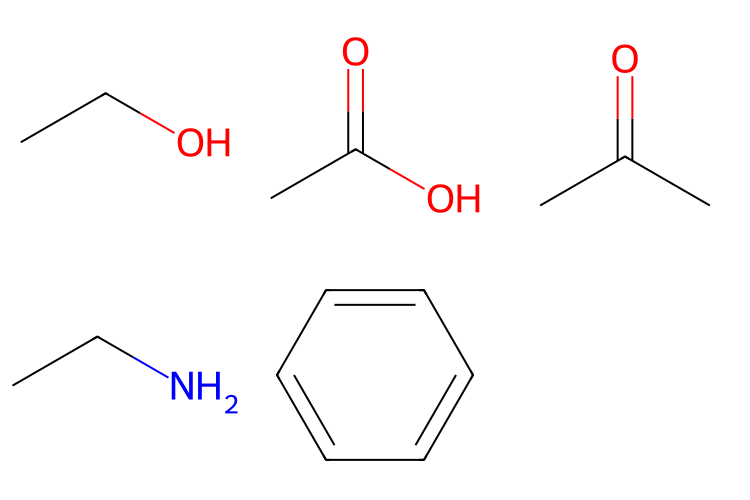


Molecules containing a carbonyl group:


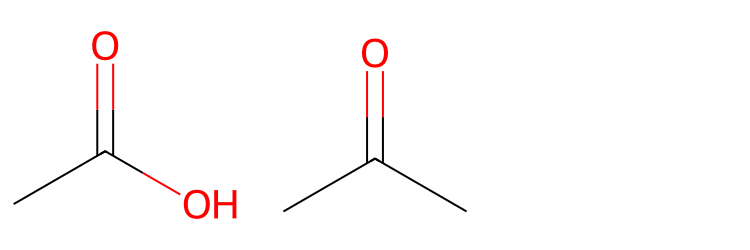

In [5]:
# List of example molecules
smiles_list = [
    "CCO",        # ethanol
    "CC(=O)O",    # acetic acid
    "CC(=O)C",    # acetone
    "CCN",        # ethylamine
    "c1ccccc1"    # benzene
]

molecules = [Chem.MolFromSmiles(smi) for smi in smiles_list]

# Show all molecules BEFORE filtering
print("All molecules (before filtering):")
display(Draw.MolsToGridImage(
    molecules,
    molsPerRow=3,
    subImgSize=(250, 250)
))

# Define SMARTS pattern for carbonyl group
smarts = "[C]=[O]"
pattern = Chem.MolFromSmarts(smarts)

# Filter molecules
filtered_mols = []

for mol in molecules:
    if mol.HasSubstructMatch(pattern):
        filtered_mols.append(mol)

# Show molecules AFTER filtering
print("\nMolecules containing a carbonyl group:")
display(Draw.MolsToGridImage(
    filtered_mols,
    molsPerRow=3,
    subImgSize=(250, 250)
))

All molecules (before filtering):


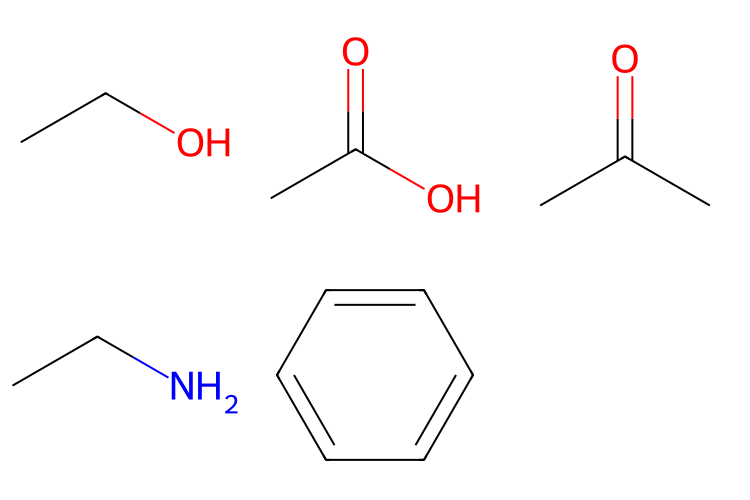


Molecules without nitrogen:


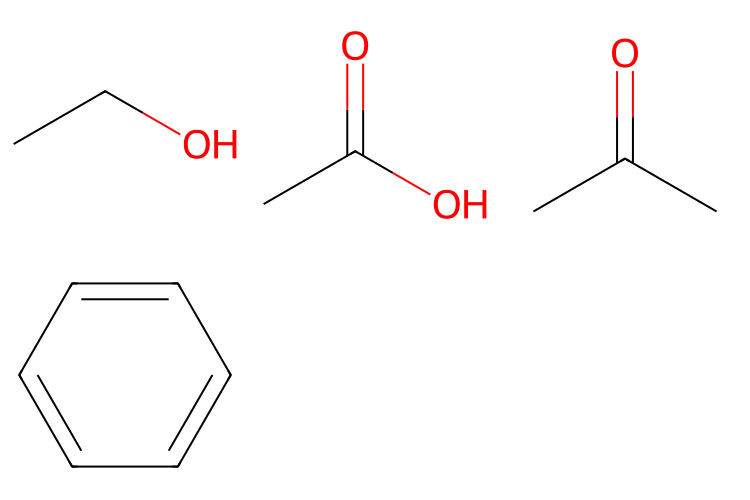

In [6]:
# Show all molecules BEFORE filtering
print("All molecules (before filtering):")
display(Draw.MolsToGridImage(
    molecules,
    molsPerRow=3,
    subImgSize=(250, 250)
))

# SMARTS pattern for nitrogen
smarts_n = "[#7]"
pattern_n = Chem.MolFromSmarts(smarts_n)

# Filtering process 
filtered_mols = []

for mol in molecules:
    if not mol.HasSubstructMatch(pattern_n):
        filtered_mols.append(mol)

# Show molecules AFTER filtering
print("\nMolecules without nitrogen:")
display(Draw.MolsToGridImage(
    filtered_mols,
    molsPerRow=3,
    subImgSize=(250, 250)
))

### Understanding `GetSubstructMatches()`

`HasSubstructMatch()` tells us if a pattern exists.  

`GetSubstructMatches()` tells us where it exists.

It returns one tuple per match, containing the atom indices involved.

This lets us locate and highlight specific substructures.

Molecule: CC(=O)C


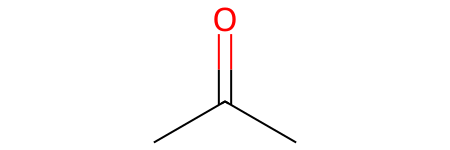

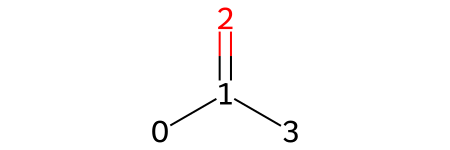

In [7]:
# Create molecule
smiles = "CC(=O)C"
mol = Chem.MolFromSmiles(smiles)
print("Molecule:", smiles)
display(mol)

# Show molecule with atom indices
for atom in mol.GetAtoms():
    atom.SetProp("atomLabel", str(atom.GetIdx()))
display(mol)


SMARTS pattern: [C]=[O]
Number of matches: 1
Matches returned: ((1, 2),)


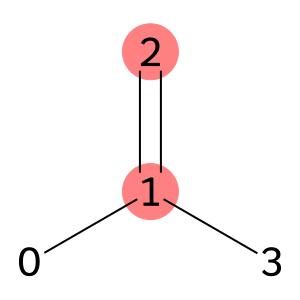

In [8]:
# Define SMARTS pattern (carbonyl group)
smarts = "[C]=[O]"
pattern = Chem.MolFromSmarts(smarts)

# Get matches
matches = mol.GetSubstructMatches(pattern)

print("\nSMARTS pattern:", smarts)
print("Number of matches:", len(matches))
print("Matches returned:", matches)

# Highlight matches
highlight_atoms = [idx for match in matches for idx in match]
display(Draw.MolToImage(
    mol,
    highlightAtoms=highlight_atoms,
    size=(300, 300)
))

### What if there is more than one match?

A SMARTS pattern can appear multiple times in the same molecule.

`GetSubstructMatches()` returns one tuple per match, each containing the atom indices involved.

This allows us to know how many times a pattern appears and where.

In [9]:
# Create molecule
smiles = "Cc1cc(O)ccc1N"
mol = Chem.MolFromSmiles(smiles)

print("Molecule:", smiles)

# SMARTS patterns
patterns = [
    "[#6]",      # Carbon atoms
    "[!#6]",     # Non-carbon atoms
    "[R]",       # Ring atoms
    "[CH3]",     # Methyl group
    "*",         # Any atom
    "[c][N]",    # carbon and nitrogen bonded atoms   
]

for smarts in patterns:
    
    pattern = Chem.MolFromSmarts(smarts)
    matches = mol.GetSubstructMatches(pattern)
    
    print("\nSMARTS:", smarts)
    print("Number of matches:", len(matches))
    print("Matches (atom indices):", matches)

Molecule: Cc1cc(O)ccc1N

SMARTS: [#6]
Number of matches: 7
Matches (atom indices): ((0,), (1,), (2,), (3,), (5,), (6,), (7,))

SMARTS: [!#6]
Number of matches: 2
Matches (atom indices): ((4,), (8,))

SMARTS: [R]
Number of matches: 6
Matches (atom indices): ((1,), (2,), (3,), (5,), (6,), (7,))

SMARTS: [CH3]
Number of matches: 1
Matches (atom indices): ((0,),)

SMARTS: *
Number of matches: 9
Matches (atom indices): ((0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (8,))

SMARTS: [c][N]
Number of matches: 1
Matches (atom indices): ((7, 8),)


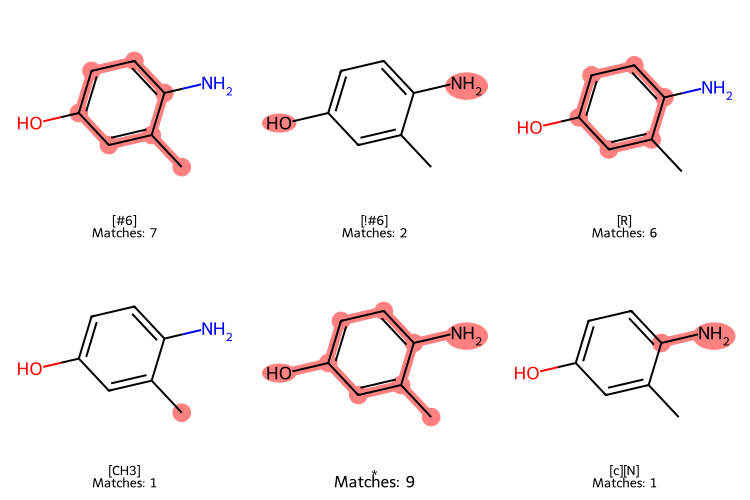

In [10]:
# Lists that will store:
# - The molecule (repeated once per SMARTS pattern)
# - The atoms to highlight for each pattern
# - The legend (text shown under each image)

mols_for_grid = []
highlights = []
legends = []

# Loop over each SMARTS pattern
for smarts in patterns:
    
    # Convert SMARTS string into an RDKit pattern object
    pattern = Chem.MolFromSmarts(smarts)
    
    # Find all matches of the pattern in the molecule
    matches = mol.GetSubstructMatches(pattern)
    
    # Collect all atom indices involved in the matches
    highlight_atoms = []
    
    for match in matches:
        for atom_idx in match:
            
            # Avoid adding duplicate atom indices
            if atom_idx not in highlight_atoms:
                highlight_atoms.append(atom_idx)
    
    # Add the same molecule to the grid (one per SMARTS pattern)
    mols_for_grid.append(mol)
    
    # Store the atoms to highlight for this SMARTS pattern
    highlights.append(highlight_atoms)
    
    # Create a legend showing the SMARTS and number of matches
    legends.append(f"{smarts}\nMatches: {len(matches)}")

# Create a grid image
img = Draw.MolsToGridImage(
    mols_for_grid,
    molsPerRow=3,              # Number of images per row
    subImgSize=(250, 250),     # Size of each molecule image
    legends=legends,           # Text shown below each molecule
    highlightAtomLists=highlights  # Atoms to highlight in each image
)

# Display the final grid
display(img)

#### 1.2. Applying SMARTS - Filtering an SDF file

Total molecules loaded: 19

All molecules in the dataset:


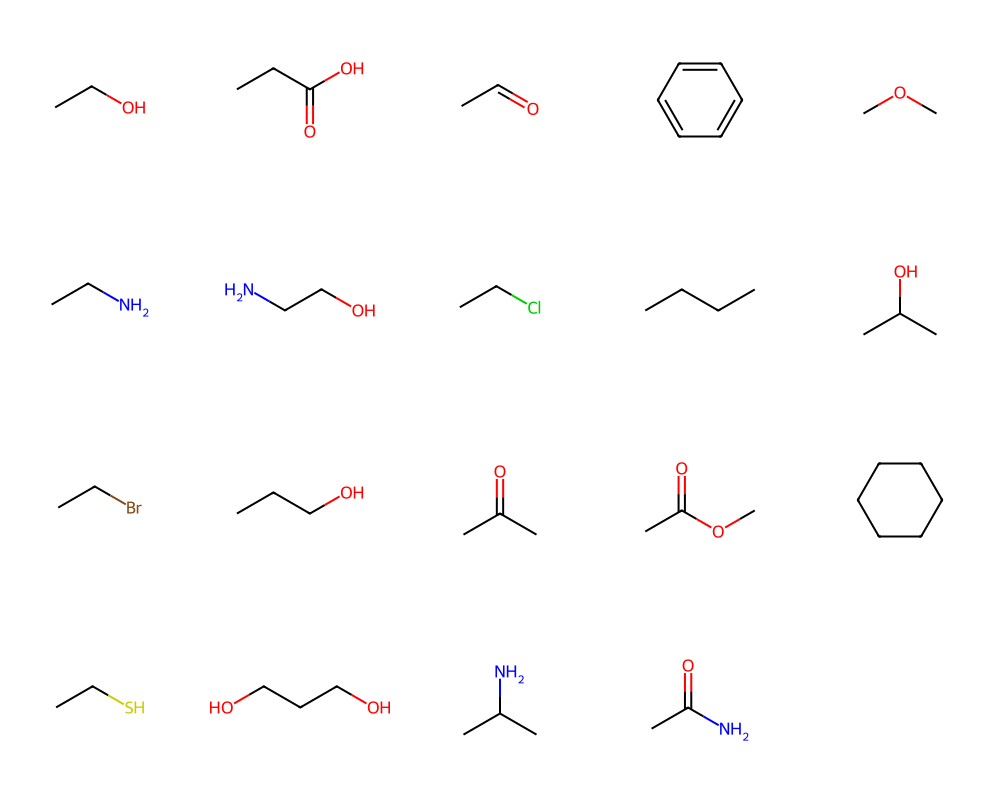


Molecules containing the pattern [CX3](=O)[#6]: 5
Molecules without the pattern: 14

Molecules containing a carbonyl carbon bonded to another carbon:


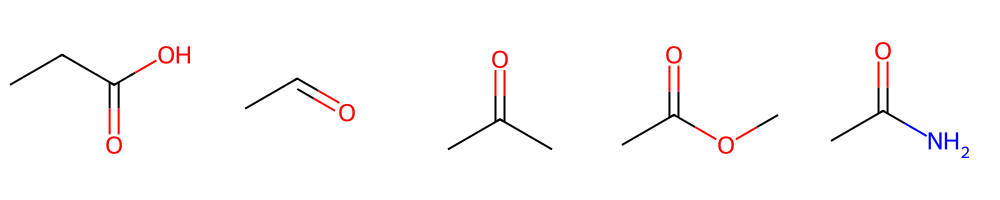

In [11]:
# 1️⃣ Load molecules from SDF
supplier = Chem.SDMolSupplier("data/sdf/sample_mols.sdf")

molecules = []
for mol in supplier:
    if mol is not None:
        molecules.append(mol)

print("Total molecules loaded:", len(molecules))

# 🔹 Show ALL molecules before filtering
print("\nAll molecules in the dataset:")
display(Draw.MolsToGridImage(
    molecules,
    molsPerRow=5,
    subImgSize=(200, 200)
))


# 2️⃣ Define SMARTS pattern
# [CX3](=O)[#6] means:
# - A carbon atom (C)
# - With three connected atoms (X3 → trigonal carbon)
# - Double bonded to oxygen (=O)
# - Single bonded to another carbon atom (#6)
#
# Important:
# This pattern will NOT match carbonyl groups where the carbonyl carbon
# is not bonded to another carbon.
#
# For example, it will NOT detect:
# - Formaldehyde (O=CH2)
# - Formic acid (O=CO)
# - Formyl chloride (O=CHCl)
#
# Because in those cases, the carbonyl carbon is not attached to a carbon atom.

# In practice, this identifies carbonyl carbons
# that are bonded to another carbon (e.g., ketones, aldehydes, etc.)
smarts = "[CX3](=O)[#6]"
pattern = Chem.MolFromSmarts(smarts)


# 3️⃣ Filter molecules using the SMARTS pattern
matched = []
unmatched = []

for mol in molecules:
    if mol.HasSubstructMatch(pattern):
        matched.append(mol)
    else:
        unmatched.append(mol)

print(f"\nMolecules containing the pattern [CX3](=O)[#6]: {len(matched)}")
print(f"Molecules without the pattern: {len(unmatched)}")


# 🔹 Show ONLY molecules that match the pattern
print("\nMolecules containing a carbonyl carbon bonded to another carbon:")
display(Draw.MolsToGridImage(
    matched,
    molsPerRow=5,
    subImgSize=(200, 200)
))

#### 1.3. Exercise 1

Does this molecule contain any oxygen atoms? Solve by applying SMART, obtaining a boolean

In [12]:
# Does this molecule contain any oxygen atoms? Solve by applying SMART, obtaining a boolean
molecule = "CCN(CC)CC"

# Your code here


SMARTS Filtering from CSV

We've prepared a CSV file containing several oxygenated compounds.

Your task is to:

- Load the CSV into a DataFrame  
- Convert the SMILES to Mol objects  
- Define a SMARTS pattern for carboxylic acid groups  
- Filter and visualize only the molecules containing carboxylic acid groups  

**Hints:**
- Be careful not to confuse carboxylic acids with aldehydes or esters.
- You can sketch in ChemDraw and use it as a starting point to derive the SMARTS pattern.

In [13]:
# Filter molecules containing carboxylic acid groups using SMARTS and visualize them
csv_file = 'data\oxygenated_compounds.csv'

# Your code here

### 2. DIGITAL CHEMICAL REACTIONS

#### 2.0. Introduction to Digital Chemical Reactions

Digital chemical reactions simulate real chemical transformations using SMARTS-based reaction templates. 

These templates define the transformation logic (reactant patterns → product structure) and can be applied programmatically using RDKit's `rdChemReactions` module.

**Common uses**:
- Automating reaction design
- Virtual synthesis of new molecules
- Filtering or modifying compound libraries

**Basic Imports for Digital Reactions**:
```python
from rdkit.Chem import rdChemReactions
```

**Structure**:
```python
rxn = rdChemReactions.ReactionFromSmarts("[C:1]=[O:2].[N:3]>>[C:1](N:3)[O:2]")
products = rxn.RunReactants((mol1, mol2))
```

**Common pitfalls**:
- Reactants must match the SMARTS pattern exactly.
- Atom mapping (`:[n]`) is essential to track atoms during transformations.
- Input molecule order matters for multi-reactant reactions.

**Resources**:
- [RDKit Reaction Guide](https://www.rdkit.org/docs/Cookbook.html#using-chemical-reactions)
- [Reaction SMARTS - Daylight](https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html)
- [SMARTS display](https://smarts.plus/)

#### 2.1. Basic examples of digital reactions

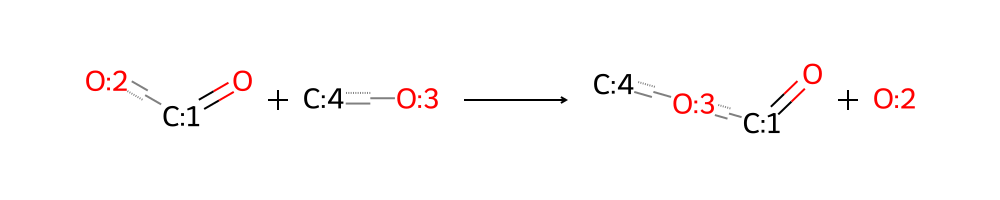

In [14]:
from rdkit import Chem
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw

# Define esterification reaction (Reaction SMARTS)
# Carboxylic acid + alcohol -> ester + leaving group
rxn_smarts = "[C:1](=O)[O:2].[O:3][C:4]>>[C:1](=O)[O:3][C:4].[O:2]"
rxn = rdChemReactions.ReactionFromSmarts(rxn_smarts)

# Define reactants
acid = Chem.MolFromSmiles("CC(=O)O")   # acetic acid
alcohol = Chem.MolFromSmiles("CO")     # methanol

# Visualize the reaction template (generic reaction)
display(Draw.ReactionToImage(rxn))

Number of product sets generated: 1
Type of 'products': <class 'tuple'>
Products: ((<rdkit.Chem.rdchem.Mol object at 0x00000240E0DABA70>, <rdkit.Chem.rdchem.Mol object at 0x00000240E0DAB680>),)


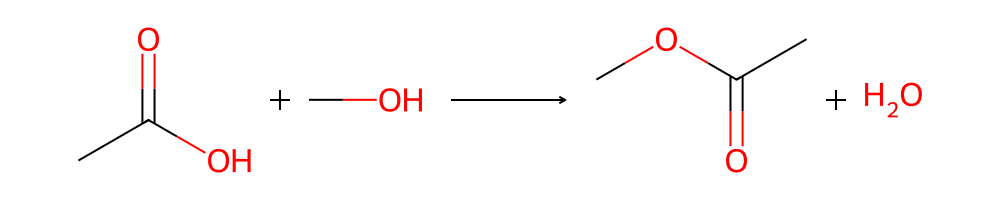

In [15]:
# Run reaction
products = rxn.RunReactants((acid, alcohol))

print("Number of product sets generated:", len(products))
print("Type of 'products':", type(products))
print("Products:", products)

# Take first product set
product_set = products[0]

# Create a reaction object with specific molecules
reaction_instance = rdChemReactions.ChemicalReaction()
reaction_instance.AddReactantTemplate(acid)
reaction_instance.AddReactantTemplate(alcohol)

for product in product_set:
    reaction_instance.AddProductTemplate(product)

# Display full reaction (reactants -> products)
display(Draw.ReactionToImage(reaction_instance))

Understanding `RunReactants()` Output

When we run:

    products = rxn.RunReactants((acid, alcohol))

RDKit does **not** return a single molecule.

Instead, it returns:

> A tuple of tuples of Mol objects.

- The **outer tuple** represents different possible ways the reaction can be applied.
- Each **inner tuple** represents the set of products generated in that reaction.

For example, in an esterification:

    acid + alcohol → ester + leaving group

Then:

- `products[0]` → first possible reaction outcome (ester + leaving group)
- `products[0][0]` → first product (typically the ester)
- `products[0][1]` → second product (leaving group)

So:

- Use `products[0]` when you want all products from one reaction outcome.
- Use `products[0][0]` when you only want a specific product.

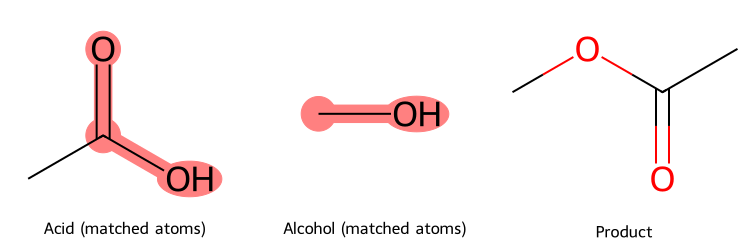

In [16]:
# Define reaction
rxn_smarts = "[C:1](=O)[O:2].[O:3][C:4]>>[C:1](=O)[O:3][C:4].[O:2]"
rxn = rdChemReactions.ReactionFromSmarts(rxn_smarts)

# Reactants
acid = Chem.MolFromSmiles("CC(=O)O")
alcohol = Chem.MolFromSmiles("CO")

# Get reactant-side SMARTS patterns
acid_pattern = Chem.MolFromSmarts("[C:1](=O)[O:2]")
alcohol_pattern = Chem.MolFromSmarts("[O:3][C:4]")

# Find matches
acid_matches = acid.GetSubstructMatches(acid_pattern)
alcohol_matches = alcohol.GetSubstructMatches(alcohol_pattern)

# Flatten indices
acid_highlight = [idx for match in acid_matches for idx in match]
alcohol_highlight = [idx for match in alcohol_matches for idx in match]

# Run reaction
products = rxn.RunReactants((acid, alcohol))
product = products[0][0]

# Visualize
display(Draw.MolsToGridImage(
    [acid, alcohol, product],
    highlightAtomLists=[acid_highlight, alcohol_highlight, []],
    legends=["Acid (matched atoms)", "Alcohol (matched atoms)", "Product"],
    subImgSize=(250, 250)
))

#### 2.1. Digital Reactions from a CSV (Automated Reaction Workflow)

Now that we understand the basic concepts, we will apply them at scale.

We will load a CSV file containing multiple molecules and apply a digital reaction to each one.

This is how digital chemistry moves from single examples to dataset-level transformations.

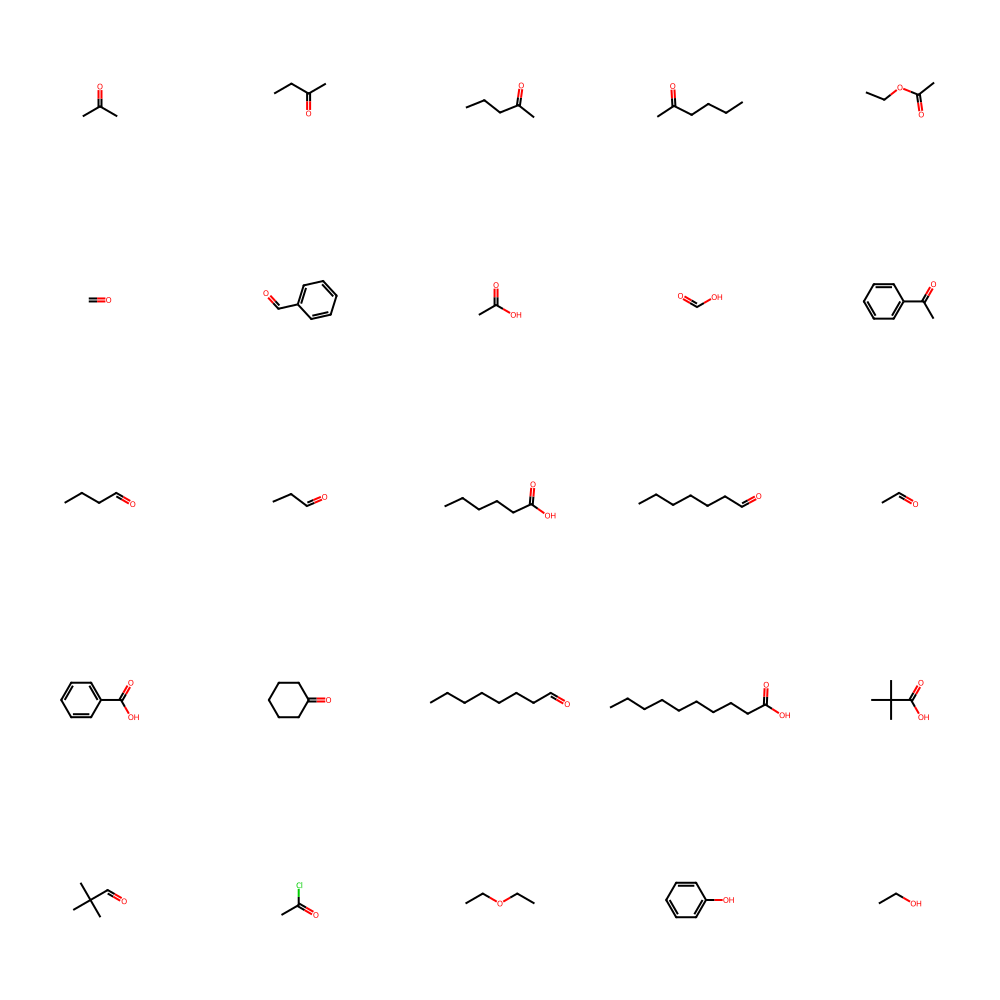

In [17]:
# Load CSV with molecules
df = pd.read_csv("data/oxygenated_compounds.csv")
df["mol_object"] = df["SMILES"].apply(Chem.MolFromSmiles)
Draw.MolsToGridImage(df["mol_object"], molsPerRow=5, subImgSize=(200, 200))
# df

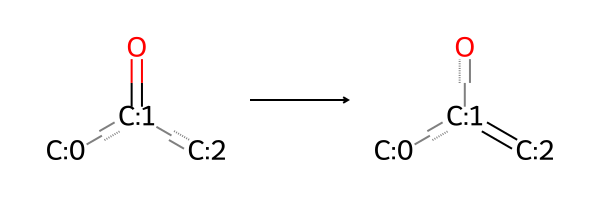

Number of successful reactions: 5


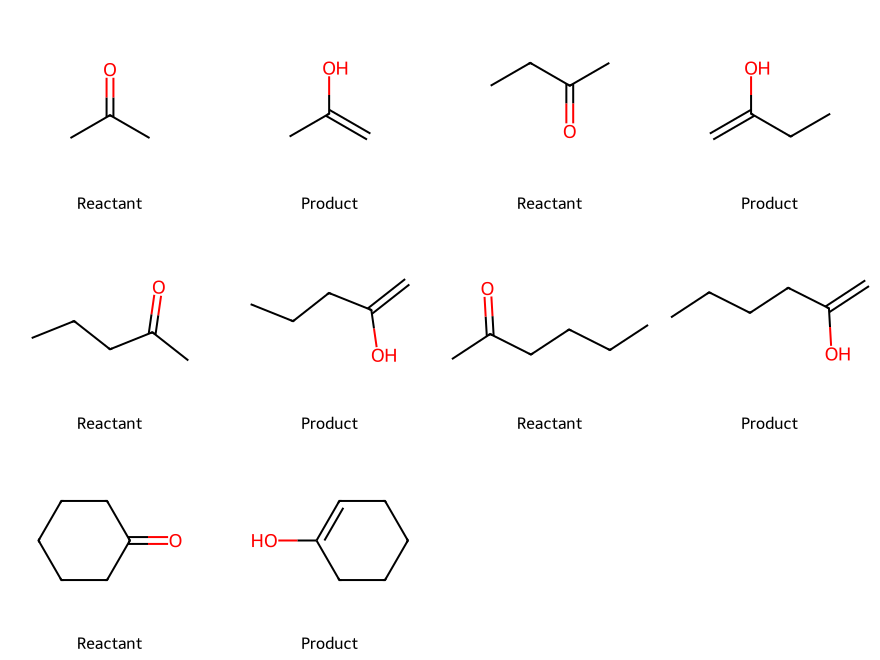

In [18]:
# Visualize original molecules
valid_mols = [mol for mol in df["mol_object"] if mol is not None]

# Define ketone → enol reaction
rxn = rdChemReactions.ReactionFromSmarts(
    "[C:0][C:1](=O)[C:2]>>[C:0][C:1](O)(=[C:2])"
)

# Apply reaction and collect results
reactants = []
products = []

for mol in valid_mols:
    ps = rxn.RunReactants((mol,))
    if ps:
        reactants.append(mol)
        products.append(ps[0][0])  # first product of first match

# Show reactant → product transformation
combined = []
legends = []

for r, p in zip(reactants, products):
    combined.extend([r, p])
    legends.extend(["Reactant", "Product"])

# Visualize generic reaction template
display(Draw.ReactionToImage(rxn))

# Visualize reactant → product transformations
print("Number of successful reactions:", len(products))
display(Draw.MolsToGridImage(
    combined,
    molsPerRow=4,
    legends=legends,
    subImgSize=(220, 220)
))

In [19]:
# Save as CSV
reactant_smiles = [Chem.MolToSmiles(r) for r in reactants]
product_smiles = [Chem.MolToSmiles(p) for p in products]

reaction_df = pd.DataFrame({
    "reactant_smiles": reactant_smiles,
    "product_smiles": product_smiles
})

reaction_df.to_csv("digital_keto_enol_products.csv", index=False)
reaction_df

,reactant_smiles,product_smiles
0,CC(C)=O,C=C(C)O
1,CCC(C)=O,C=C(O)CC
2,CCCC(C)=O,C=C(O)CCC
3,CCCCC(C)=O,C=C(O)CCCC
4,O=C1CCCCC1,OC1=CCCCC1


#### 2.3. Multicomponent Digital Reactions

In this section, we will simulate a multicomponent cycloaddition to generate pyridine-like structures.

We will work with two datasets:

- `alkynes.sdf` (terminal alkynes)
- `nitriles.sdf`

We will:

- Load all alkynes and nitriles
- Define a Reaction SMARTS rule describing the transformation
- Apply the reaction across all 6 × 6 combinations
- Collect, deduplicate, and visualize the generated products

**Chemical Concept**

This transformation represents a formal **[2+2+2] cycloaddition**, where:

- Two C≡C units
- One C≡N unit

Combine to form a six-membered aromatic heterocycle (a pyridine core).

Because different orientations are possible during cyclization, multiple regioisomers may be generated (up to four in some cases).

Important Considerations

- The SMARTS must correctly identify terminal alkynes and nitriles.
- Atom mapping is essential to track how atoms rearrange during ring formation.
- The same alkyne must participate twice in the reaction.
- Canonical SMILES will be used to identify and remove duplicate products.

We will begin by inspecting the structures in both SDF files and then design the reaction logic accordingly.

Number of alkynes loaded: 6
Number of nitriles loaded: 6

Alkynes:


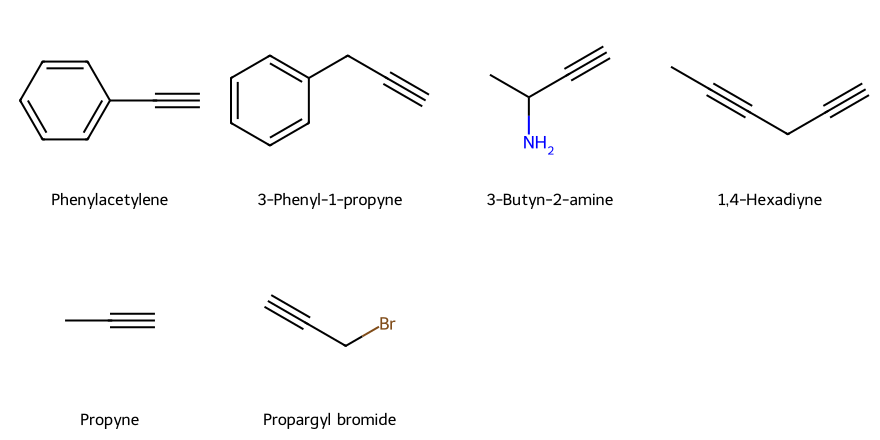


Nitriles:


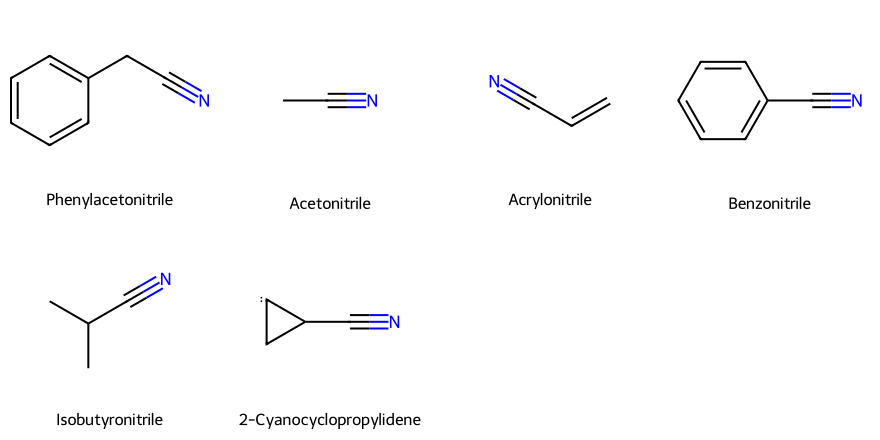

In [20]:
# Load SDF files
alkyne_supplier = SDMolSupplier("data/sdf/alkynes_reducido.sdf")
nitrile_supplier = SDMolSupplier("data/sdf/nitriles_reducido.sdf")

# Extract molecules 
alkynes_raw = [
    (mol, mol.GetProp("_Name"))
    for mol in alkyne_supplier
    if mol is not None
]

nitriles_raw = [
    (mol, mol.GetProp("_Name"))
    for mol in nitrile_supplier
    if mol is not None
]

print(f"Number of alkynes loaded: {len(alkynes_raw)}")
print(f"Number of nitriles loaded: {len(nitriles_raw)}")

# Visualize original structures
print("\nAlkynes:")
display(Draw.MolsToGridImage(
    [mol for mol, name in alkynes_raw],
    legends=[name for mol, name in alkynes_raw],
    molsPerRow=4,
    subImgSize=(220, 220)
))

print("\nNitriles:")
display(Draw.MolsToGridImage(
    [mol for mol, name in nitriles_raw],
    legends=[name for mol, name in nitriles_raw],
    molsPerRow=4,
    subImgSize=(220, 220)
))

# Create versions WITH explicit hydrogens for reaction processing
alkynes = [(Chem.AddHs(mol), name) for mol, name in alkynes_raw]
nitriles = [(Chem.AddHs(mol), name) for mol, name in nitriles_raw]

Defined 4 regioisomeric reactions.
Reaction list: [('conf_1', <rdkit.Chem.rdChemReactions.ChemicalReaction object at 0x00000240E0FFECE0>), ('conf_2', <rdkit.Chem.rdChemReactions.ChemicalReaction object at 0x00000240E0FFE7A0>), ('conf_3', <rdkit.Chem.rdChemReactions.ChemicalReaction object at 0x00000240E0FFEE30>), ('conf_4', <rdkit.Chem.rdChemReactions.ChemicalReaction object at 0x00000240E0FFEEA0>)]

Reaction template: conf_1


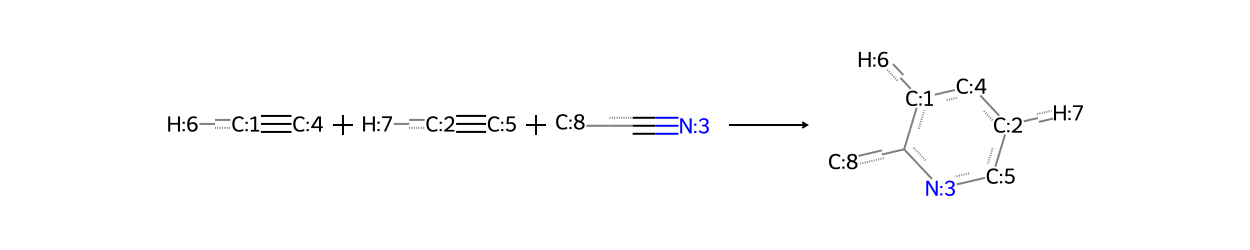


Reaction template: conf_2


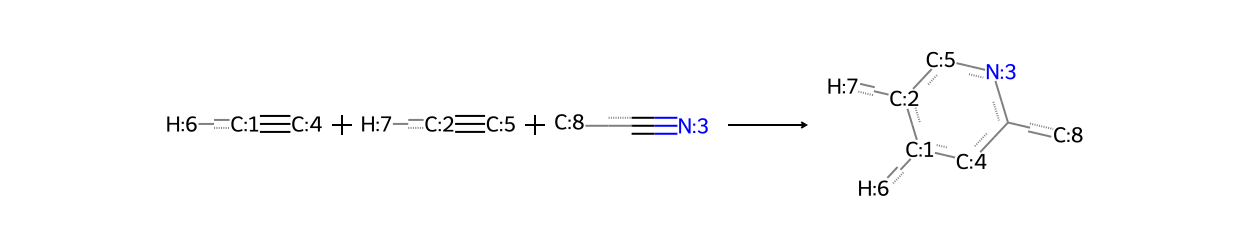


Reaction template: conf_3


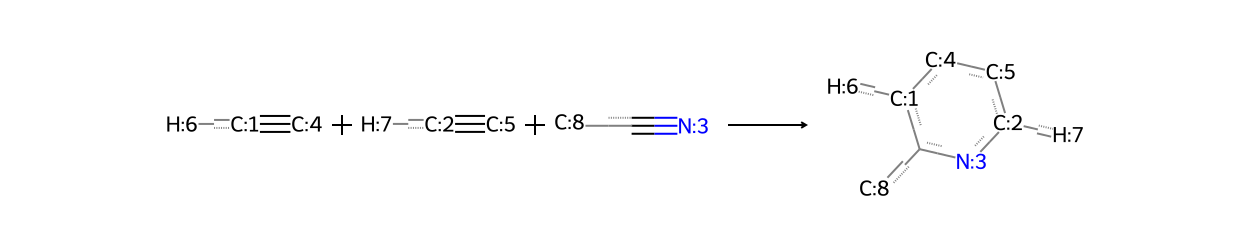


Reaction template: conf_4


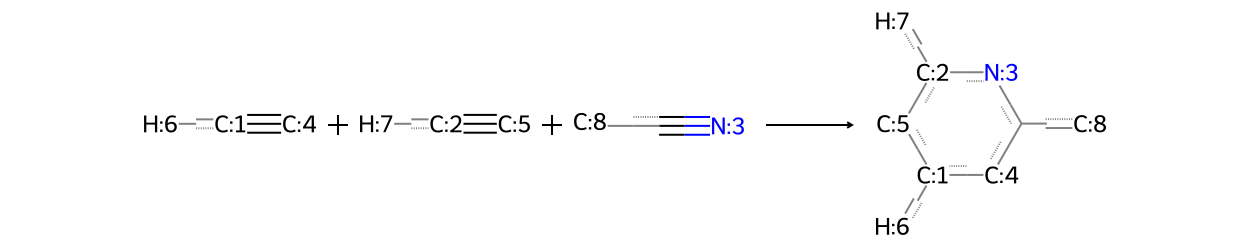

In [21]:
# Define pyridine-forming reactions
# 2 alkynes + 1 nitrile → pyridine (4 regioisomers)
reaction_list = [
    ("conf_1", rdChemReactions.ReactionFromSmarts(
        "[H:6][C:1]#[C:4].[H:7][C:2]#[C:5].[#6:8][C]#[N:3]>>"
        "c1([#6:8])[c:1]([H:6])[c:4][c:2]([H:7])[c:5][n:3]1"
    )),
    ("conf_2", rdChemReactions.ReactionFromSmarts(
        "[H:6][C:1]#[C:4].[H:7][C:2]#[C:5].[#6:8][C]#[N:3]>>"
        "c1([#6:8])[c:4][c:1]([H:6])[c:2]([H:7])[c:5][n:3]1"
    )),
    ("conf_3", rdChemReactions.ReactionFromSmarts(
        "[H:6][C:1]#[C:4].[H:7][C:2]#[C:5].[#6:8][C]#[N:3]>>"
        "c1([#6:8])[c:1]([H:6])[c:4][c:5][c:2]([H:7])[n:3]1"
    )),
    ("conf_4", rdChemReactions.ReactionFromSmarts(
        "[H:6][C:1]#[C:4].[H:7][C:2]#[C:5].[#6:8][C]#[N:3]>>"
        "c1([#6:8])[c:4][c:1]([H:6])[c:5][c:2]([H:7])[n:3]1"
    )),
]

print(f"Defined {len(reaction_list)} regioisomeric reactions.")
print("Reaction list:",reaction_list)

# Visualize reaction templates
for label, rxn in reaction_list:
    
    print(f"\nReaction template: {label}")
    
    display(Draw.ReactionToImage(
        rxn,
        subImgSize=(250, 250)
    ))

In [35]:
# Apply reactions to all alkyne–nitrile combinations
product_data = []
product_counter = 1

# Loop over all combinations of alkynes, nitriles, and reaction templates
for alkyne_mol, alkyne_name in alkynes:
    for nitrile_mol, nitrile_name in nitriles:
        for conf_label, rxn in reaction_list:

            try:
                # Run the reaction with the current alkyne and nitrile as reactants
                results = rxn.RunReactants((alkyne_mol, alkyne_mol, nitrile_mol))

                # Process each product generated by the reaction
                for result in results:
                    mol = result[0]
                    if mol is None:
                        continue

                    # Standardize the product molecule (optional but recommended)
                    Chem.SanitizeMol(mol)
                    mol = Chem.RemoveHs(mol)
                    smi = Chem.MolToSmiles(mol, canonical=True)

                    # Store product information in a list of dictionaries
                    product_data.append({
                        "product_name": f"py_{product_counter}",
                        "product_smiles": smi,
                        "alkyne": alkyne_name,
                        "nitrile": nitrile_name,
                        "regioisomer": conf_label
                    })

                    product_counter += 1

            except Exception:
                continue

In [36]:
# Create DataFrame
df_pyridines = pd.DataFrame(product_data)

# Remove duplicate structures
print("Total products generated:", len(df_pyridines))

# Remove duplicate products based on SMILES
df_pyridines.to_csv("data/pyridine_products.csv", index=False)

# Visualize generated pyridines
df_pyridines

Total products generated: 144


,product_name,product_smiles,alkyne,nitrile,regioisomer
0,py_1,c1ccc(Cc2cc(-c3ccccc3)cc(-c3ccccc3)n2)cc1,Phenylacetylene,Phenylacetonitrile,conf_1
1,py_2,c1ccc(Cc2nc(-c3ccccc3)ccc2-c2ccccc2)cc1,Phenylacetylene,Phenylacetonitrile,conf_2
2,py_3,c1ccc(Cc2cc(-c3ccccc3)c(-c3ccccc3)cn2)cc1,Phenylacetylene,Phenylacetonitrile,conf_3
3,py_4,c1ccc(Cc2ncc(-c3ccccc3)cc2-c2ccccc2)cc1,Phenylacetylene,Phenylacetonitrile,conf_4
4,py_5,Cc1cc(-c2ccccc2)cc(-c2ccccc2)n1,Phenylacetylene,Acetonitrile,conf_1
...,...,...,...,...,...
139,py_140,CC(C)c1ncc(CBr)cc1CBr,Propargyl bromide,Isobutyronitrile,conf_4
140,py_141,BrCc1cc(CBr)nc(C2[C]C2)c1,Propargyl bromide,2-Cyanocyclopropylidene,conf_1
141,py_142,BrCc1ccc(CBr)c(C2[C]C2)n1,Propargyl bromide,2-Cyanocyclopropylidene,conf_2
142,py_143,BrCc1cnc(C2[C]C2)cc1CBr,Propargyl bromide,2-Cyanocyclopropylidene,conf_3


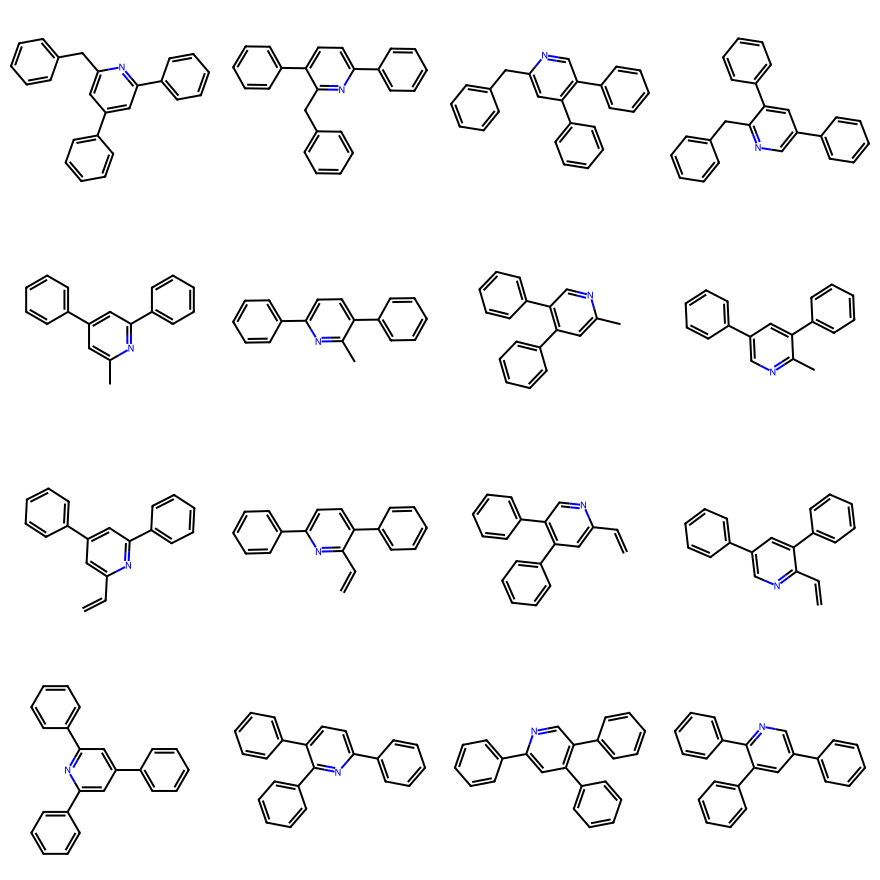

Unique pyridine products: 144


In [37]:
# Visualize generated pyridines
df_pyridines["mol_object"] = df_pyridines["product_smiles"].apply(Chem.MolFromSmiles)

display(Draw.MolsToGridImage(
    df_pyridines["mol_object"][:16],
    molsPerRow=4,
    subImgSize=(220, 220)
))

# Important note: Remove duplicate structures
df_pyridines = df_pyridines.drop_duplicates(subset="product_smiles")

print("Unique pyridine products:", len(df_pyridines))

#### 2.4. Real-World Example: Digital Generation of Metal Complexes

So far, we have used SMARTS and digital reactions to model organic transformations.

We started with single-component reactions applied to one molecule. Then we explored multi-component reactions (e.g., 2+1 systems) and applied them across multiple SMILES in a dataset.

---

Now we move to a more realistic and experimentally relevant case: **metal-mediated transformations**.

This example is based on a real research project involving Mn-complex formation.

### Why are these complexes interesting?

These Mn systems are relevant in catalytic C–H functionalization and asymmetric oxidation processes:

<p align="center">
  <img src="data/images/mn_catalysis.png" width="600">
</p>

They enable selective oxidation with high enantioselectivity and practical yields, making them valuable in sustainable catalysis.

---

### Digital Representation of the Coordination Process

In this notebook, we will simulate the formation of Mn–carboxylate complexes from:

- A predefined manganese core structure
- A series of organic carboxylic acids

Instead of modeling a single isolated reaction, we will apply **sequential reaction steps** to automatically generate a library of metal–ligand complexes.

The digital transformation we will model corresponds to:

<p align="center">
  <img src="data/images/mn_coordination.jpg" width="600">
</p>


This mirrors an actual inorganic workflow: combining a metal core with different ligands to explore structural and catalytic diversity.

Number of acids: 5
Number of metal cores: 5

Carboxylic acids:


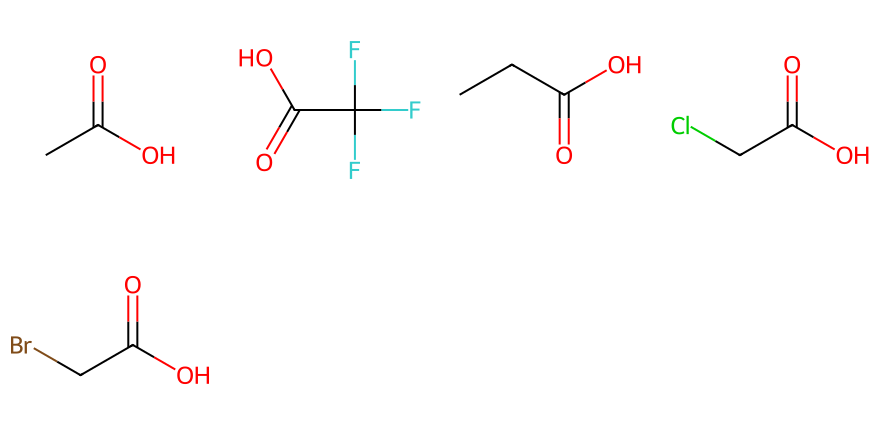


Metal cores:


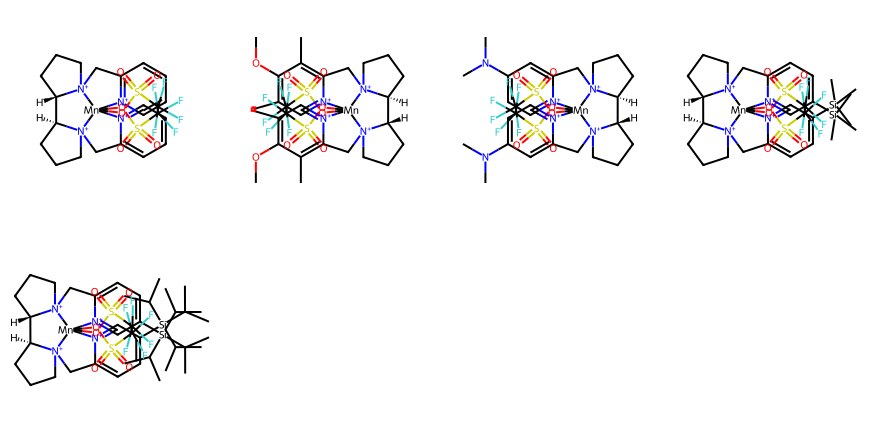

In [26]:
# Load input data from CSV files
df_acids = pd.read_csv("data/acids.csv")
df_cores = pd.read_csv("data/cores.csv")

print("Number of acids:", len(df_acids))
print("Number of metal cores:", len(df_cores))

# Convert SMILES to Mol objects
acids = []
cores = []

for smi in df_acids["smiles"]:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        acids.append(mol)

for smi in df_cores["smiles"]:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        cores.append(mol)

# Visualize acids
print("\nCarboxylic acids:")
display(Draw.MolsToGridImage(
    acids,
    molsPerRow=4,
    subImgSize=(220, 220)
))

#  Visualize metal cores
print("\nMetal cores:")
display(Draw.MolsToGridImage(
    cores,
    molsPerRow=4,
    subImgSize=(220, 220)
))

Step 1 — Acid activation


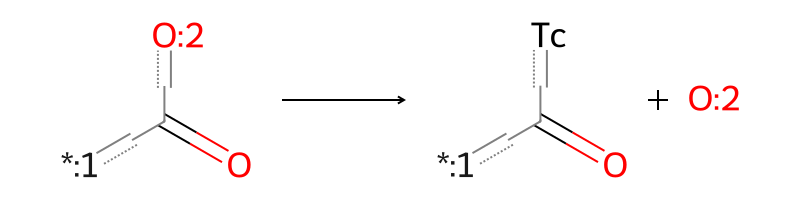

Step 2 — Mn coordination


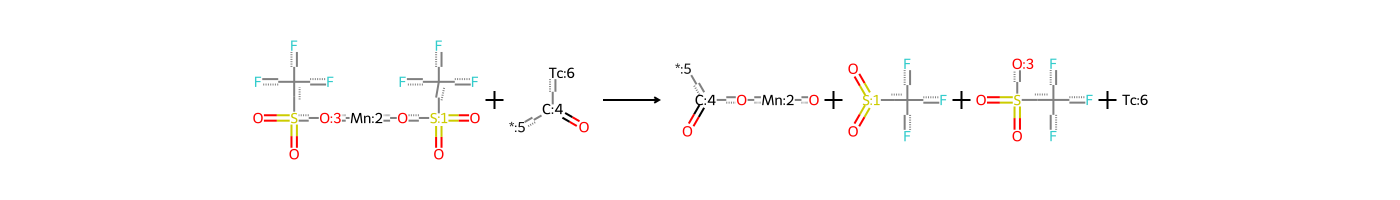

In [27]:
# Sequential metal–ligand reaction (real project)
def reaction(core, acid):
    """
    Core formation from acid plus Mn-structure

    """

    # Step 1 — Activate acid (replace OH with Tc placeholder)
    rxn1 = rdChemReactions.ReactionFromSmarts(
        'O=C([OH:2])[*:1]>>O=C([*:1])[Tc].[OH:2]'
    )

    reacts1 = (Chem.MolFromSmiles(acid),)
    products_1 = rxn1.RunReactants(reacts1)
    # print(Chem.MolToSmiles(products_1[0][0]))

    if not products_1:
        return None

    # Step 2 — Create Mn–O2CR bond
    rxn2 = rdChemReactions.ReactionFromSmarts(
        'O=[S:1](O[Mn:2][O:3]S(=O)(C(F)(F)F)=O)(C(F)(F)F)=O.'
        'O=[C:4]([Tc:6])[*:5]>>'
        '[*:5][C:4](O[Mn:2]O)=O.'
        'O=[S:1](C(F)(F)F)=O.'
        'O=S([O:3])(C(F)(F)F)=O.'
        '[Tc:6]'
    )

    reacts2 = (
        Chem.MolFromSmiles(core),
        products_1[0][0]
    )

    products_2 = rxn2.RunReactants(reacts2)

    if not products_2:
        return None

    product = products_2[0][0]
    Chem.SanitizeMol(product)

    return Chem.MolToSmiles(product, canonical=True)

# Visualize reaction steps
rxn1 = rdChemReactions.ReactionFromSmarts(
    'O=C([OH:2])[*:1]>>O=C([*:1])[Tc].[OH:2]'
)

rxn2 = rdChemReactions.ReactionFromSmarts(
    'O=[S:1](O[Mn:2][O:3]S(=O)(C(F)(F)F)=O)(C(F)(F)F)=O.'
    'O=[C:4]([Tc:6])[*:5]>>'
    '[*:5][C:4](O[Mn:2]O)=O.'
    'O=[S:1](C(F)(F)F)=O.'
    'O=S([O:3])(C(F)(F)F)=O.'
    '[Tc:6]'
)

print("Step 1 — Acid activation")
display(Draw.ReactionToImage(rxn1))

print("Step 2 — Mn coordination")
display(Draw.ReactionToImage(rxn2))

In [28]:
# Generate metal complexes library
product_data = []
counter = 1

for core in df_cores["smiles"]:
    for acid in df_acids["smiles"]:

        result = reaction(core, acid)

        if result is not None:
            product_data.append({
                "product_name": f"Mn_complex_{counter}",
                "product_smiles": result,
                "core": core,
                "acid": acid
            })
            counter += 1

df_complexes = pd.DataFrame(product_data)
print("Total complexes generated:", len(df_complexes))
df_complexes

Total complexes generated: 25


,product_name,product_smiles,core,acid
0,Mn_complex_1,CC(=O)[O][Mn]123([OH])[n+]4ccccc4C[N+]14CCC[C@...,O=S(O[Mn]123([N+]4=C(C=CC=C4)C[N+]15CCC[C@H]5[...,CC(O)=O
1,Mn_complex_2,O=C([O][Mn]123([OH])[n+]4ccccc4C[N+]14CCC[C@H]...,O=S(O[Mn]123([N+]4=C(C=CC=C4)C[N+]15CCC[C@H]5[...,OC(C(F)(F)F)=O
2,Mn_complex_3,CCC(=O)[O][Mn]123([OH])[n+]4ccccc4C[N+]14CCC[C...,O=S(O[Mn]123([N+]4=C(C=CC=C4)C[N+]15CCC[C@H]5[...,OC(CC)=O
3,Mn_complex_4,O=C(CCl)[O][Mn]123([OH])[n+]4ccccc4C[N+]14CCC[...,O=S(O[Mn]123([N+]4=C(C=CC=C4)C[N+]15CCC[C@H]5[...,OC(CCl)=O
4,Mn_complex_5,O=C(CBr)[O][Mn]123([OH])[n+]4ccccc4C[N+]14CCC[...,O=S(O[Mn]123([N+]4=C(C=CC=C4)C[N+]15CCC[C@H]5[...,OC(CBr)=O
5,Mn_complex_6,COc1c(C)c[n+]2c(c1C)C[N+]13CCC[C@H]1[C@@H]1CCC...,CC1=C(C(C)=C2[N+]([Mn]34(OS(=O)(C(F)(F)F)=O)(O...,CC(O)=O
6,Mn_complex_7,COc1c(C)c[n+]2c(c1C)C[N+]13CCC[C@H]1[C@@H]1CCC...,CC1=C(C(C)=C2[N+]([Mn]34(OS(=O)(C(F)(F)F)=O)(O...,OC(C(F)(F)F)=O
7,Mn_complex_8,CCC(=O)[O][Mn]123([OH])[n+]4cc(C)c(OC)c(C)c4C[...,CC1=C(C(C)=C2[N+]([Mn]34(OS(=O)(C(F)(F)F)=O)(O...,OC(CC)=O
8,Mn_complex_9,COc1c(C)c[n+]2c(c1C)C[N+]13CCC[C@H]1[C@@H]1CCC...,CC1=C(C(C)=C2[N+]([Mn]34(OS(=O)(C(F)(F)F)=O)(O...,OC(CCl)=O
9,Mn_complex_10,COc1c(C)c[n+]2c(c1C)C[N+]13CCC[C@H]1[C@@H]1CCC...,CC1=C(C(C)=C2[N+]([Mn]34(OS(=O)(C(F)(F)F)=O)(O...,OC(CBr)=O


🧪 Exercise — Digital Amide Formation

In this exercise, you will simulate a simple synthetic route using digital reactions.

1. From a mixed set of molecules, first identify:
   - Which compounds contain a **carboxylic acid** group.
   - Which compounds contain a **primary amine**.

2. Use only those identified molecules as reactants for the next step.

3. Define a Reaction SMARTS that models **amide formation**:

   Carboxylic acid + primary amine → amide 

4. Apply the reaction to all valid acid–amine combinations.

5. Visualize the generated amide products.

This exercise mirrors a basic synthetic planning workflow:

Functional group identification → Reactant selection → Reaction rule → Product generation.


In [29]:
smiles_list = [
    "CC(=O)O",      # acetic acid
    "CCC(=O)O",     # propionic acid
    "CN",           # methylamine
    "CCN",          # ethylamine
    "CCO"           # alcohol (should not react)
]

# Your code here

------------------------------
## 🔎 Solutions

This section contains the suggested solutions for all exercises in the notebook.

Try to complete the exercises on your own before reviewing the answers. The goal is not only to obtain the correct output, but to understand the underlying concepts.

------------------------------

In [38]:
#################################################
# Exercise 1 — Oxygen presence (SMARTS + Boolean)
#################################################

mol = Chem.MolFromSmiles("CCN(CC)CC")

# Define SMARTS pattern for oxygen
oxygen_pattern = Chem.MolFromSmarts("[#8]")

contains_oxygen = mol.HasSubstructMatch(oxygen_pattern)

print("Molecule: CCN(CC)CC")
print("Contains oxygen:", contains_oxygen)

Molecule: CCN(CC)CC
Contains oxygen: False


Total molecules: 25
Molecules containing carboxylic acid group: 6


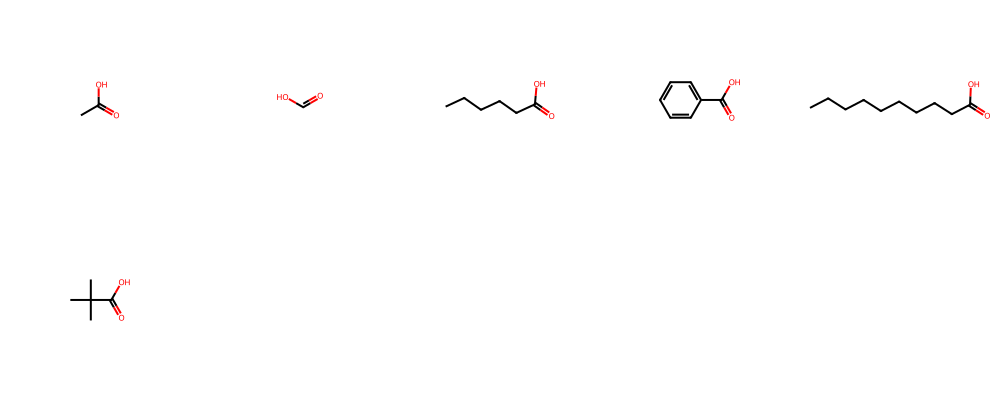

In [39]:
#################################################
# Exercise 2 — Filter carboxylic acids from CSV
#################################################

# Load CSV
df = pd.read_csv("data/oxygenated_compounds.csv")

# Convert SMILES to Mol objects
molecules = []

for smi in df["SMILES"]:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mol = Chem.AddHs(mol) #<----- add hydrogens to the molecule to ensure the carboxylic acid pattern is correctly identified      
        molecules.append(mol)

print("Total molecules:", len(molecules))

# Using [CX3](=O)[OH] more specific than O=CO[H]
# [CX3](=O)[OH] means:
# - C      → carbon atom
# - X3     → with three connected atoms (trigonal carbon, typical for carbonyls)
# - (=O)   → double bonded to oxygen
# - OX2H1  → oxygen with two connections and one hydrogen (i.e., an OH group)
#
# Define SMARTS pattern for carboxylic acid
acid_pattern = Chem.MolFromSmarts("O=CO[H]")

matched = []

for mol in molecules:
    if mol.HasSubstructMatch(acid_pattern):
        mol = Chem.RemoveHs(mol)  # Remove hydrogens for cleaner visualization
        matched.append(mol)

print("Molecules containing carboxylic acid group:", len(matched))

# Visualize matched molecules
display(Draw.MolsToGridImage(
    matched,
    molsPerRow=5,
    subImgSize=(200, 200)
))

Acids found: 2
Primary amines found: 2


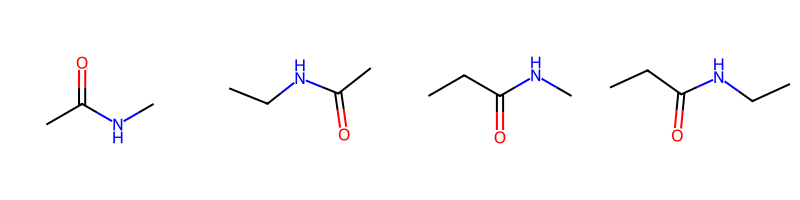

In [42]:
#######################################
# Exercise 3 — Digital Amide Formation
#######################################

# 1️⃣ Create molecules
smiles_list = [
    "CC(=O)O",      # acetic acid
    "CCC(=O)O",     # propionic acid
    "CN",           # methylamine
    "CCN",          # ethylamine
    "CCO"           # alcohol (should not react)
]

molecules = [Chem.MolFromSmiles(smi) for smi in smiles_list]

# 2️⃣ Define SMARTS patterns
acid_pattern = Chem.MolFromSmarts("[CX3](=O)[OH]")
amine_pattern = Chem.MolFromSmarts("[NX3;H2]")

acids = []
amines = []

for mol in molecules:
    if mol.HasSubstructMatch(acid_pattern):
        acids.append(mol)
    if mol.HasSubstructMatch(amine_pattern):
        amines.append(mol)

print("Acids found:", len(acids))
print("Primary amines found:", len(amines))

# 3️⃣ Define amide formation reaction
rxn = rdChemReactions.ReactionFromSmarts(
    "[CX3:1](=O)[OX2H1].[NX3;H2:2]>>[CX3:1](=O)[NX3:2]"
)

# 4️⃣ Apply reaction
products = []

for acid in acids:
    for amine in amines:
        ps = rxn.RunReactants((acid, amine))
        if ps:
            products.append(ps[0][0])

# 5️⃣ Visualize products
display(Draw.MolsToGridImage(products, molsPerRow=4))